In [ ]:
!wget https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip

!unzip -q dataset-resized.zip -d dataset_sampah

import os
base_dir = '/content/dataset_sampah/dataset-resized'
print("Dataset berhasil diunduh dan diekstrak ke:", base_dir)

--2026-06-24 20:18:12--  https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip
Resolving huggingface.co (huggingface.co)... 13.35.202.34, 13.35.202.97, 13.35.202.40, ...
Connecting to huggingface.co (huggingface.co)|13.35.202.34|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cas-bridge.xethub.hf.co/xet-bridge-us/647949fffaa0a209531b9a2b/154a5f61da453c05242f7483d1ed8c1ccd55a3e81f6072629109f4b5fc891193?Expires=1782335892&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly9jYXMtYnJpZGdlLnhldGh1Yi5oZi5jby94ZXQtYnJpZGdlLXVzLzY0Nzk0OWZmZmFhMGEyMDk1MzFiOWEyYi8xNTRhNWY2MWRhNDUzYzA1MjQyZjc0ODNkMWVkOGMxY2NkNTVhM2U4MWY2MDcyNjI5MTA5ZjRiNWZjODkxMTkzKiIsIkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc4MjMzNTg5Mn19fV19&Signature=MEQCIBMiy34ThcZRH5kpBCL7Pj9KvO4pQB8G7t7feGQ6k0ztAiBB9o5KlTYn2F%7EfO%7EQuE9%7EWHVTfGuYDrL%7EBt6MIHc9KZw__&Key-Pair-Id=K1LYXO563TGWFU&response-content-disposition=inline%3B+filename*%3DUTF-8%

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator
 (
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

print("Memuat Data Latih:")
train_generator = datagen.flow_from_directory
 (
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

print("Memuat Data Validasi:")
validation_generator = datagen.flow_from_directory
 (
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Memuat Data Latih:
Found 2024 images belonging to 6 classes.
Memuat Data Validasi:
Found 503 images belonging to 6 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential
 ([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
EPOCHS = 30

history = model.fit
 (
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 347ms/step - accuracy: 0.2925 - loss: 1.6554 - val_accuracy: 0.2664 - val_loss: 1.6237
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.4205 - loss: 1.3844 - val_accuracy: 0.3797 - val_loss: 1.4697
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.4664 - loss: 1.3288 - val_accuracy: 0.3956 - val_loss: 1.4892
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.5311 - loss: 1.2071 - val_accuracy: 0.4533 - val_loss: 1.3660
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.5623 - loss: 1.1352 - val_accuracy: 0.4970 - val_loss: 1.2812
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.5830 - loss: 1.1104 - val_accuracy: 0.4831 - val_loss: 1.2938
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.5716 - loss: 1.1281 - val_accuracy: 0.5050 - val_loss: 1.2742
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.6097 - loss: 1.0334 - val_accu

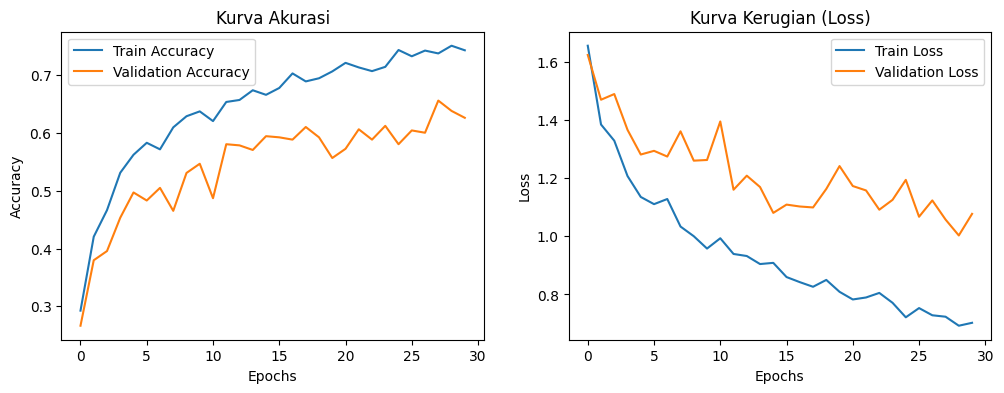

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Kurva Akurasi')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kurva Kerugian (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Menyiapkan data uji...
Found 503 images belonging to 6 classes.
Model sedang memprediksi gambar, harap tunggu sebentar...
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 427ms/step


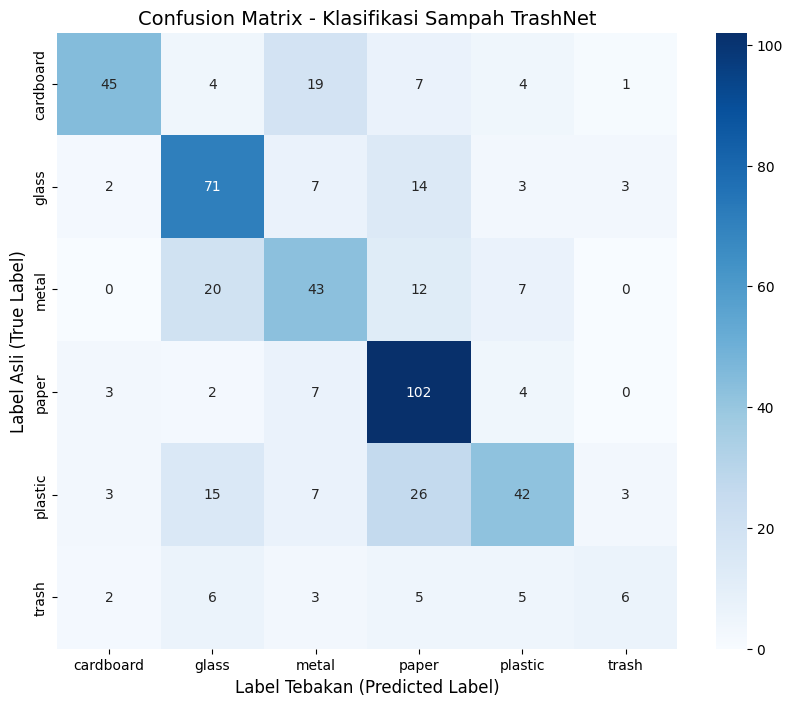

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Menyiapkan data uji...")
test_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Model sedang memprediksi gambar, harap tunggu sebentar...")
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Klasifikasi Sampah TrashNet', fontsize=14)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Label Tebakan (Predicted Label)', fontsize=12)
plt.show()